### **Install Required Libraries**

In [1]:
!pip install transformers datasets accelerate evaluate shap lime seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/275.7 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 266.2/275.7 kB 11.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


### **Import Libraries**

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import time

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from lime.lime_text import LimeTextExplainer

### **Check GPU**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


### **Load Dataset**

In [ ]:
dataset = load_dataset("fancyzhx/amazon_polarity")
dataset

### **Create Smaller Subset for Colab**

In [5]:
train_dataset = dataset['train'].shuffle(seed=42).select(range(20000))
test_dataset = dataset['test'].shuffle(seed=42).select(range(5000))

split = train_dataset.train_test_split(test_size=0.2)

train_dataset = split['train']
val_dataset = split['test']

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['label', 'title', 'content'],
    num_rows: 16000
})
Dataset({
    features: ['label', 'title', 'content'],
    num_rows: 4000
})
Dataset({
    features: ['label', 'title', 'content'],
    num_rows: 5000
})


In [6]:
raw_test_dataset = test_dataset

### **Load Tokenizer**

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

### **Tokenization Function**

In [8]:
def tokenize_function(example):
    return tokenizer(
        example['content'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

### **Apply Tokenization**

In [ ]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

### **Set Dataset Format**

In [10]:
train_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label'],
    output_all_columns=True
)

val_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label'],
    output_all_columns=True
)

test_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label'],
    output_all_columns=True
)

### **Load Transformer Model**

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device)

### **Define Evaluation Metrics**

In [12]:
def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='binary'
    )

    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

### **Training Arguments**

In [13]:
training_args = TrainingArguments(
    output_dir='./results',

    eval_strategy='epoch',

    save_strategy='epoch',

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_dir='./logs',

    logging_steps=100,

    load_best_model_at_end=True,

    fp16=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### **Create Trainer**

In [14]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

### **Train Model**

In [ ]:
trainer.train()

### **Evaluate Model**

In [ ]:
results = trainer.evaluate(test_dataset)

results

### **Generate Predictions**

In [17]:
predictions = trainer.predict(test_dataset)

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

### **Classification Report**

In [18]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      2453
           1       0.88      0.95      0.91      2547

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



### **Confusion Matrix**

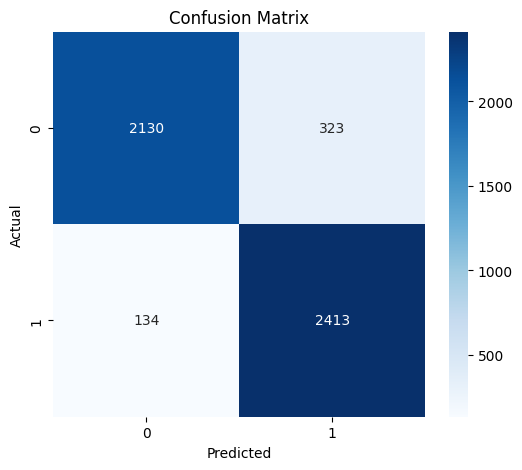

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### **Save Model**

In [ ]:
model.save_pretrained("amazon_sentiment_model")
tokenizer.save_pretrained("amazon_sentiment_model")

### **Attention Extraction Setup**

In [ ]:
attention_model = AutoModelForSequenceClassification.from_pretrained(
    "amazon_sentiment_model",
    output_attentions=True
)

attention_model.to(device)
attention_model.eval()

### **Select Sample Text**

In [22]:
sample_text = test_dataset[0]['content']

sample_text

'The product works fine. I ordered the more exprensive one after I read reviews from others on Amazon. My husband likes the presser. It does a good job pressing his pants. However, it was damaged in the box when we received it. We decided it was too much trouble to send it back. The box was torn and the presser had a chuck knocked out of it.'

### **Tokenize Sample**

In [23]:
inputs = tokenizer(
    sample_text,
    return_tensors='pt',
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {k: v.to(device) for k, v in inputs.items()}

### **Extract Attention Weights**

In [24]:
with torch.no_grad():
    outputs = attention_model(**inputs)

attentions = outputs.attentions

len(attentions)

6

### **Convert Tokens**

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(
    inputs['input_ids'][0]
)

tokens[:20]

### **Visualize Attention Head 1 Layer 1**

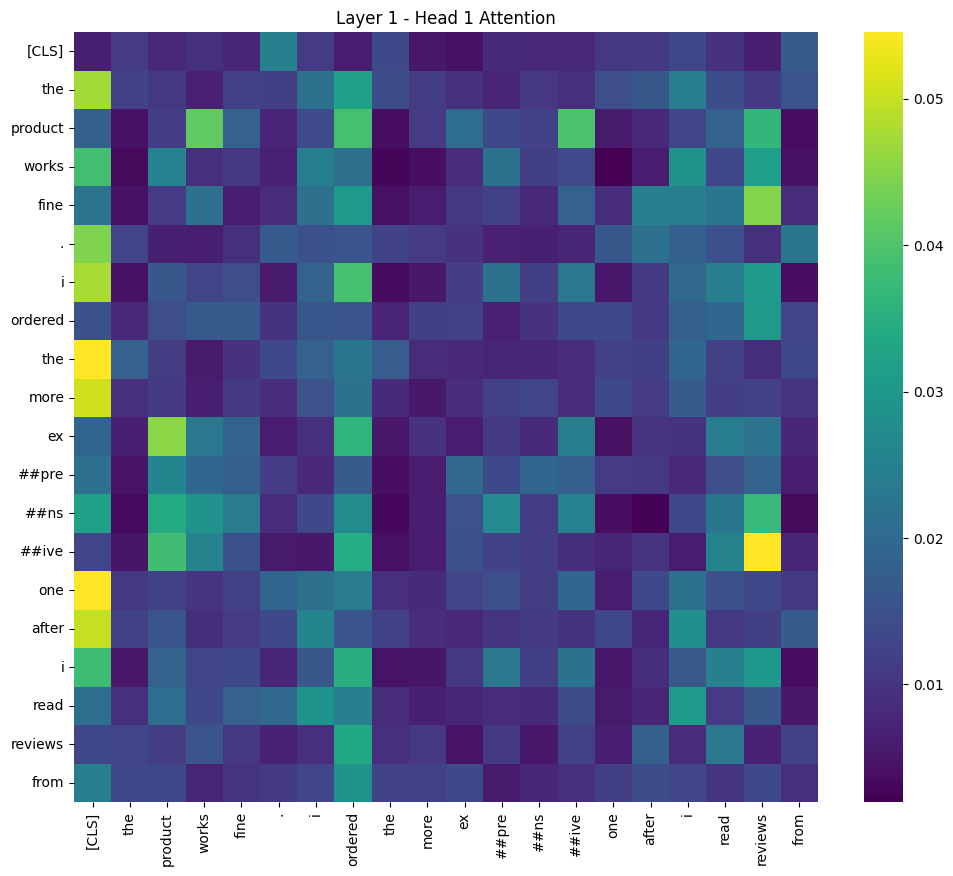

In [26]:
attention = attentions[0][0][0].cpu().numpy()

plt.figure(figsize=(12,10))

sns.heatmap(
    attention[:20, :20],
    xticklabels=tokens[:20],
    yticklabels=tokens[:20],
    cmap='viridis'
)

plt.title("Layer 1 - Head 1 Attention")
plt.show()

### **Visualize Attention Head 2 Layer 2**

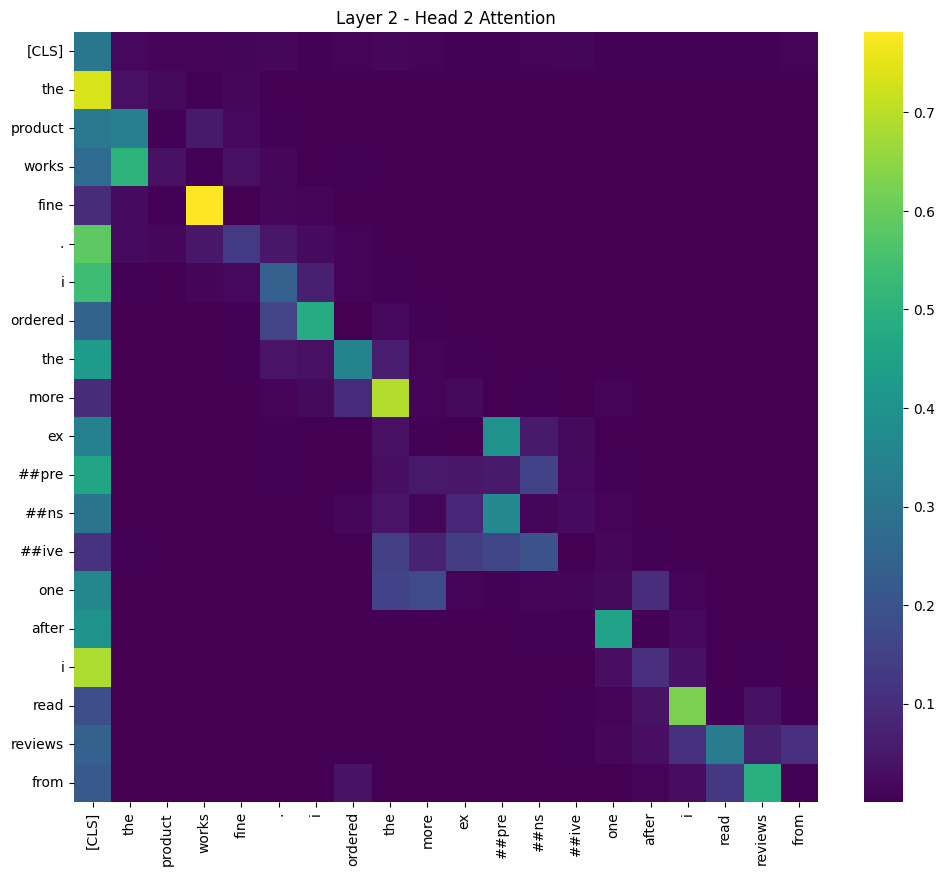

In [27]:
attention = attentions[1][0][1].cpu().numpy()

plt.figure(figsize=(12,10))

sns.heatmap(
    attention[:20, :20],
    xticklabels=tokens[:20],
    yticklabels=tokens[:20],
    cmap='viridis'
)

plt.title("Layer 2 - Head 2 Attention")
plt.show()

In [28]:
import gc
import torch

# Move model to CPU
model = model.cpu()

# Clear GPU memory
torch.cuda.empty_cache()
gc.collect()

20132

### **Create Hugging Face Pipeline**

In [29]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1
)

### **SHAP Explainer**

In [30]:
masker = shap.maskers.Text(tokenizer)

explainer = shap.Explainer(
    classifier,
    masker
)

### **SHAP Explanation Example**

In [ ]:
sample = raw_test_dataset[1]['content'][:300]

shap_values = explainer(
    [sample],
    max_evals=50
)

shap.plots.text(shap_values[0])

### **Generate 20 SHAP Explanations**

In [ ]:
for i in range(20):

    text = raw_test_dataset[i]['content']

    print(f"\nSHAP Explanation {i+1}\n")

    shap_values = explainer([text])

    shap.plots.text(shap_values[0])

### **Initialize LIME Explainer**

In [33]:
lime_explainer = LimeTextExplainer(
    class_names=['negative', 'positive']
)

### **LIME Explanation Example**

In [37]:
def predict_proba(texts):
    model.eval()
    all_probs = []

    # Process in small batches to avoid OOM
    batch_size = 8
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,       # ← truncate long inputs
            padding=True
        ).to(device)

        with torch.no_grad():     # ← no gradient graph built
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

        # Free GPU memory immediately after each batch
        del inputs, outputs
        torch.cuda.empty_cache()

    return np.vstack(all_probs)

In [ ]:
sample = raw_test_dataset[2]['content']

exp = lime_explainer.explain_instance(
    sample,
    predict_proba,
    num_features=10
)

exp.show_in_notebook(text=True)

### **Generate 20 LIME Explanations**

In [ ]:
for i in range(20):

    text = raw_test_dataset[i]['content']

    print(f"\nLIME Explanation {i+1}\n")

    exp = lime_explainer.explain_instance(
        text,
        predict_proba,
        num_features=10
    )

    exp.show_in_notebook(text=True)

### **Runtime Comparison**

In [40]:
sample = raw_test_dataset[0]['content']

### **Measure SHAP Runtime**

In [41]:
start = time.time()

shap_values = explainer([sample])

shap_time = time.time() - start

print("SHAP Runtime:", shap_time)

SHAP Runtime: 3.718708038330078


### **Measure LIME Runtime**

In [42]:
start = time.time()

exp = lime_explainer.explain_instance(
    sample,
    predict_proba,
    num_features=10
)

lime_time = time.time() - start

print("LIME Runtime:", lime_time)

LIME Runtime: 6.66515040397644


### **Runtime Comparison Plot**

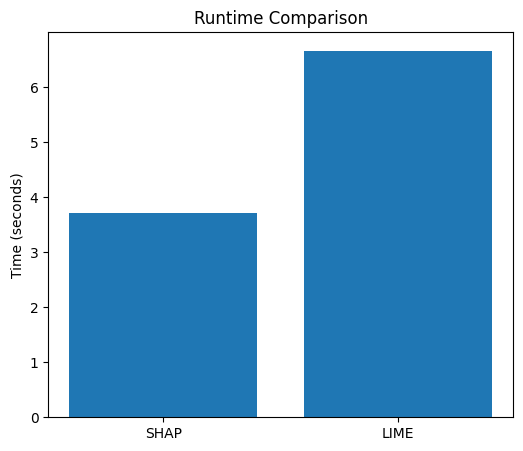

In [43]:
methods = ['SHAP', 'LIME']
times = [shap_time, lime_time]

plt.figure(figsize=(6,5))

plt.bar(methods, times)

plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison")

plt.show()

### **Misclassified Samples**

In [44]:
misclassified = []

for i in range(len(y_true)):

    if y_true[i] != y_pred[i]:

        misclassified.append(i)

len(misclassified)

457

### **Display Misclassified Examples**

In [45]:
for i in misclassified[:10]:

    print("\nTEXT:\n")
    print(test_dataset[i]['content'])

    print("\nTRUE LABEL:", y_true[i])
    print("PREDICTED:", y_pred[i])

    print("-"*80)


TEXT:

The product works fine. I ordered the more exprensive one after I read reviews from others on Amazon. My husband likes the presser. It does a good job pressing his pants. However, it was damaged in the box when we received it. We decided it was too much trouble to send it back. The box was torn and the presser had a chuck knocked out of it.

TRUE LABEL: 1
PREDICTED: 0
--------------------------------------------------------------------------------

TEXT:

1.Music-I don't like it,but too overplayed for this CD-2/5 stars2.Most Girls-I listen a lot when gets boring-4/5 stars3.Bent-Good rock tune-5/5 stars4.Everything You Want-I like Vertical Horizon,this song is bad-1/5 stars5.Deep Inside Of You-Good punk tune-5/5 stars6.Pinch Me-Great pop tune-5/5 stars7.The Way You Love Me-An ultimate love song,but little annoying-3.5/5 stars8.Here With Me-One of my favorites-5/5 stars9.He Wasn't Man Enough For Me-Good song,but too overplayed-4/5 stars10.What A Girl Wants-Annoying,depressing son

### **Training Summary**

In [46]:
print("Final Results")

print(results)

Final Results
{'eval_loss': 0.2353885918855667, 'eval_accuracy': 0.9086, 'eval_precision': 0.8819444444444444, 'eval_recall': 0.9473890851982725, 'eval_f1': 0.9134961196289987, 'eval_runtime': 7.6376, 'eval_samples_per_second': 654.658, 'eval_steps_per_second': 40.982, 'epoch': 2.0}
